# ZnO Thermal Conductivity
## MACE · Phonopy · Phono3py · RTA · Full LBTE · vs DFT · vs Experiment

**One notebook, 2 external filea needed (DFT.yaml and mace-omat-0-medium.model).** Run cells top-to-bottom.

```
ZnO wurtzite structure
        │
        ├─ MACE relaxation          (CPU)
        │
        ├─ Phonopy (FC2)  ──► phonon dispersion  ──► vs DFT (DFT.yaml)
        │
        └─ Phono3py (FC3) ──► real scattering rates
                    │
                    ├─ FC2 + RTA          ──► κ_FC2_RTA(T)   (simplified)
                    ├─ FC3 + RTA          ──► κ_FC3_RTA(T)   (fast)
                    └─ FC3 + Full LBTE    ──► κ_FC3_LBTE(T)  (accurate)
                                │
                                └─ All vs Experimental data
```

---

## Theory


### Force constants
- **FC2** — harmonic, single displacements → phonon dispersions
- **FC3** — anharmonic, pairs of displacements → phonon scattering rates

### Three levels of κ calculation
| Method | FC used | Accuracy |
|--------|---------|----------|----------|
| FC2 + RTA | FC2 only | rough |
| FC3 + RTA | FC3  | good |
| FC3 + Full LBTE | best |

### CPU
| Backend | `DEVICE` | `dtype` |
|---------|----------|---------|
| CPU | `'cpu'` | `'float64'` |

---

## Step 0 — Install All Required Packages


In [1]:
import subprocess, sys, platform



def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

packages = [
    'numpy',
    'scipy',
    'matplotlib',
    'pyyaml',      # to read DFT.yaml
    'ase',
    'phonopy',
    'phono3py',
    'torch',      
    'e3nn',
    'mace-torch',
    'ipykernel',
]

for pkg in packages:
    print(f'  Installing {pkg}...')
    pip_install(pkg)

# Register kernel so you can always find it in Jupyter
subprocess.check_call([
    sys.executable, '-m', 'ipykernel', 'install',
    '--user', '--name', 'zno_arm64',
    '--display-name', 'Python (arm64 ZnO)'
])

import torch
print(f'\n All packages installed.')
print(f'   PyTorch  : {torch.__version__}')


  Installing numpy...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/nguyen/zno_venv/bin/python -m pip install --upgrade pip


  Installing scipy...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/nguyen/zno_venv/bin/python -m pip install --upgrade pip


  Installing matplotlib...


...

  Installing mace-torch...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/nguyen/zno_venv/bin/python -m pip install --upgrade pip


  Installing ipykernel...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/nguyen/zno_venv/bin/python -m pip install --upgrade pip


Installed kernelspec zno_arm64 in /Users/nguyen/Library/Jupyter/kernels/zno_arm64

 All packages installed.
   PyTorch  : 2.11.0


In [2]:
import urllib.request, os


MODEL_FILE = 'mace-omat-0-medium.model'

if os.path.exists(MODEL_FILE):
    size_mb = os.path.getsize(MODEL_FILE) / 1e6
    print(f' Model already present: {MODEL_FILE}  ({size_mb:.1f} MB)')
else:
    print('mace-omat-0-medium.model (~79.5 MB) not found')


 Model already present: mace-omat-0-medium.model  (79.5 MB)


---
## Step 1 — Imports & Configuration

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from time import time
import yaml
import torch

from ase import Atoms
from ase.build import bulk
from ase.optimize import LBFGS

from phonopy import Phonopy
from phonopy.structure.atoms import PhonopyAtoms
from phonopy.units import THzToEv, Kb, Hbar
from phono3py import Phono3py
from mace.calculators import MACECalculator

# ═══════════════════════════════════════════════════════════════════
#  USER CONFIGURATION
# ═══════════════════════════════════════════════════════════════════
MODEL_PATH = 'mace-omat-0-medium.model'
DFT_YAML   = 'DFT.yaml'          # path to your DFT phonon file

# Auto-detect device
if  torch.cuda.is_available():
    DEVICE = 'cuda'
    DTYPE  = 'float64'
else:
    DEVICE = 'cpu'
    DTYPE  = 'float64'

SC2_MATRIX     = [4, 4, 4]    # FC2 supercell
DISPLACEMENT_2 = 0.01         # Å
SC3_MATRIX     = [2, 2, 2]    # FC3 supercell 
DISPLACEMENT_3 = 0.03         # Å
Q_MESH         = [15, 15, 15]
TEMP_MIN_C     = 25
TEMP_MAX_C     = 700
N_TEMPS        = 30

print(' Configuration ready.')
print(f'   Device        : {DEVICE}  (dtype={DTYPE})')
print(f'   FC2 supercell : {SC2_MATRIX}')
print(f'   FC3 supercell : {SC3_MATRIX}')
print(f'   q-mesh        : {Q_MESH}')
print(f'   Temperature   : {TEMP_MIN_C}–{TEMP_MAX_C} °C')

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
 Configuration ready.
   Device        : cpu  (dtype=float64)
   FC2 supercell : [4, 4, 4]
   FC3 supercell : [2, 2, 2]
   q-mesh        : [15, 15, 15]
   Temperature   : 25–700 °C


---
## Step 2 Experimental thermal conductivity
Digitized from paper. Original units **W·K⁻¹·cm⁻¹** → ×100 → **W·m⁻¹·K⁻¹**.


In [4]:
# ── Experimental κ ───────────────────────────────────────────────
_s = 100.0   # W·K⁻¹·cm⁻¹ → W·m⁻¹·K⁻¹

exp_ZnO = np.array([
    [25,   0.470], [75,   0.360], [200,  0.250],
    [325,  0.192], [440,  0.148], [545,  0.115], [640,  0.095],
])
exp_ZnO[:, 1] *= _s


print(f'Experimental ZnO: {exp_ZnO[0,1]:.0f} W/mK at 25°C  →  {exp_ZnO[-1,1]:.0f} W/mK at 640°C')




Experimental ZnO: 47 W/mK at 25°C  →  10 W/mK at 640°C


---
## Step 3 — Helper Functions

In [5]:
def get_calc():
    return MACECalculator(
        model_paths=MODEL_PATH,
        device=DEVICE,
        default_dtype=DTYPE
    )

def ase_to_phonopy(atoms):
    return PhonopyAtoms(
        symbols=atoms.get_chemical_symbols(),
        cell=atoms.cell[:],
        positions=atoms.positions
    )

def phonopy_to_ase(ph_atoms):
    return Atoms(
        symbols=ph_atoms.symbols,
        positions=ph_atoms.positions,
        cell=ph_atoms.cell,
        pbc=True
    )

def evaluate_forces(supercells, label=''):
    """Evaluate MACE forces. Handles None entries. Prints ETA every 5%."""
    calc    = get_calc()
    forces  = []
    n_valid = sum(1 for s in supercells if s is not None)
    t0      = time()
    done    = 0
    step    = max(1, n_valid // 20)

    for scell in supercells:
        if scell is None:
            forces.append(None)
            continue
        ase_atoms = phonopy_to_ase(scell)
        ase_atoms.calc = calc
        forces.append(ase_atoms.get_forces().astype(np.float64))
        done += 1
        if done % step == 0 or done == 1:
            elapsed = time() - t0
            eta = elapsed / done * (n_valid - done)
            print(f'  {label:6s}  {done:4d}/{n_valid}  '
                  f'elapsed {elapsed:5.0f}s  ETA {eta:5.0f}s')

    print(f'  {label} — {n_valid} supercells in {time()-t0:.0f}s')
    return forces

print('Helper functions ready.')

Helper functions ready.


---
## Step 4 — Build & Relax ZnO Structure

In [6]:
atoms = bulk('ZnO', 'wurtzite', a=3.25, c=5.2)
print(f'Primitive cell: {len(atoms)} atoms,  volume = {atoms.get_volume():.3f} Å³')

print(f'\nRelaxing with MACE on {DEVICE}...')
calc = get_calc()
atoms.calc = calc
opt = LBFGS(atoms, logfile=None)
opt.run(fmax=0.0001)


print(f' Relaxed in {opt.get_number_of_steps()} steps')
print(f'   Volume  = {atoms.get_volume():.3f} Å³')
max_force = np.sqrt((atoms.get_forces()**2).sum(axis=1)).max()
print(f'   Max F   = {max_force * 1000:.2f} meV/Å')

relaxed_atoms = atoms

Primitive cell: 4 atoms,  volume = 47.566 Å³

Relaxing with MACE on cpu...
 Relaxed in 3 steps
   Volume  = 47.566 Å³
   Max F   = 0.01 meV/Å


---
## Step 5 — 2nd-Order Force Constants (FC2)

In [7]:
ph_atoms = ase_to_phonopy(relaxed_atoms)
phonon   = Phonopy(ph_atoms, supercell_matrix=SC2_MATRIX)
phonon.generate_displacements(distance=DISPLACEMENT_2)
sc2 = phonon.supercells_with_displacements
print(f'FC2: {len(sc2)} supercells  ({len(sc2[0])} atoms each)')

phonon.forces = evaluate_forces(sc2, label='FC2')
phonon.produce_force_constants()
print('\n FC2 done.')

# Γ-point sanity check
phonon.run_qpoints([[0, 0, 0]])
freqs_G = phonon.get_qpoints_dict()['frequencies'][0]
print('\nPhonon frequencies at Γ (THz):')
for i, f in enumerate(freqs_G):
    tag  = 'acoustic' if i < 3 else 'optical '
    warn = '  check relaxation!' if (i < 3 and abs(f) > 0.5) else ''
    print(f'  Branch {i+1:2d} ({tag}): {f:7.3f} THz{warn}')



FC2: 4 supercells  (256 atoms each)
  FC2        1/4  elapsed     2s  ETA     5s
  FC2        2/4  elapsed     3s  ETA     3s
  FC2        3/4  elapsed     4s  ETA     1s
  FC2        4/4  elapsed     5s  ETA     0s
  FC2 — 4 supercells in 5s

 FC2 done.

Phonon frequencies at Γ (THz):
  Branch  1 (acoustic):  -0.000 THz
  Branch  2 (acoustic):  -0.000 THz
  Branch  3 (acoustic):  -0.000 THz
  Branch  4 (optical ):   2.548 THz
  Branch  5 (optical ):   2.548 THz
  Branch  6 (optical ):   7.460 THz
  Branch  7 (optical ):  11.416 THz
  Branch  8 (optical ):  12.116 THz
  Branch  9 (optical ):  12.116 THz
  Branch 10 (optical ):  13.097 THz
  Branch 11 (optical ):  13.097 THz
  Branch 12 (optical ):  16.151 THz


---
## Step 6 — Phonon Dispersion: MACE vs DFT

We compute the MACE phonon dispersion along the same BZ path as the DFT calculation  
(**Γ → M → K → Γ → A → L → H → A**) and overlay both.

In [8]:
import torch
import numpy as np
from ase.build import bulk
from ase.io import write
from ase.optimize import BFGS
from ase.filters import UnitCellFilter
from ase import Atoms
from mace.calculators import MACECalculator

# For phonon dispersion with phonopy:
from phonopy import Phonopy
from phonopy.structure.atoms import PhonopyAtoms

# === Utility function to convert ASE Atoms to PhonopyAtoms ===
def prepare_phonopy_structure(ase_atoms):
    cell = ase_atoms.get_cell()
    scaled_positions = ase_atoms.get_scaled_positions()
    symbols = ase_atoms.get_chemical_symbols()
    return PhonopyAtoms(symbols=symbols, scaled_positions=scaled_positions, cell=cell)
# === Function to calculate force constants using MACE ===
def calculate_force_constants(atoms, supercell_matrix=[2, 2, 2], displacement=0.01):
    """Calculate force constants using MACE"""
    phonopy_atoms = prepare_phonopy_structure(atoms)
    phonon = Phonopy(phonopy_atoms, supercell_matrix=supercell_matrix)
    
    phonon.generate_displacements(distance=displacement)
    supercells = phonon.supercells_with_displacements
    
    calc = MACECalculator(
        model_paths="mace-omat-0-medium.model",  # Changed from model_paths to model_path
        device="cuda" if torch.cuda.is_available() else "cpu",
        default_dtype="float64"
    )
    
    force_sets = []
    print(f"Calculating force constants with {len(supercells)} displacements")
    
    for i, scell in enumerate(supercells):
        displaced = Atoms(
            symbols=scell.symbols,
            positions=scell.positions,
            cell=scell.cell,
            pbc=True
        )
        displaced.calc = calc
        forces = displaced.get_forces()
        force_sets.append(forces)
    
    phonon.forces = np.array(force_sets)  # Convert to numpy array
    phonon.produce_force_constants()
    return phonon

# === Step 1: Build and relax ideal ZnO structure ===
zno = bulk('ZnO', crystalstructure='wurtzite', a=3.25, c=5.2)
zno.calc = calc

ucf = UnitCellFilter(zno, hydrostatic_strain=True)
opt = BFGS(ucf, trajectory='zno_relax.traj', logfile='zno_relax.log')
opt.run(fmax=0.0001)

write("POSCAR", zno, format='vasp')
print("Relaxed structure saved to POSCAR")

# === Step 2: Phonon force constants ===
supercell_matrix = [3, 3, 3]  # adjust size as needed
phonon = calculate_force_constants(zno, supercell_matrix=supercell_matrix, displacement=0.01)

# === Step 3: Phonon band structure ===
import seekpath
import matplotlib.pyplot as plt

# Get high-symmetry path from seekpath
structure = (
    zno.cell,
    zno.get_scaled_positions(),
    zno.get_atomic_numbers()
)
seekpath_result = seekpath.get_path(structure)

# Extract band path and special points
path = seekpath_result["path"]
point_coords = seekpath_result["point_coords"]

print("# High-symmetry k-points (fractional in primitive reciprocal lattice)")
for label in ["GAMMA", "M", "K", "GAMMA", "A", "L", "H", "A"]:
    coords = point_coords[label]
    print(f"{label:>2} : {coords}")

print("\n# Path sequence:")
for start, end in path:
    print(f"{start} -> {end}")
    
# Prepare band path for phonopy
bands = []
for segment in path:
    q_start = np.array(point_coords[segment[0]])
    q_end = np.array(point_coords[segment[1]])
    band = []
    for i in range(101):
        frac = i / 100.0
        q = (1 - frac) * q_start + frac * q_end
        band.append(q)
    bands.append(band)

# Create band path with labels
path_connections = [True] * (len(bands) - 1)  # Connect all segments
labels = [segment[0] for segment in path] + [path[-1][1]]

# Calculate band structure
phonon.run_band_structure(bands, path_connections=path_connections, labels=labels)

# Get the band structure data directly
frequencies = phonon.get_band_structure_dict()['frequencies']
distances = phonon.get_band_structure_dict()['distances']
qpoints = phonon.get_band_structure_dict()['qpoints']

# === Save band structure to YAML ===
phonon.write_yaml_band_structure(filename="MACE.yaml")
print("Phonon band structure saved to MACE.yaml (text YAML format)")


Relaxed structure saved to POSCAR
Calculating force constants with 4 displacements
# High-symmetry k-points (fractional in primitive reciprocal lattice)
GAMMA : [0.0, 0.0, 0.0]
 M : [0.5, 0.0, 0.0]
 K : [0.3333333333333333, 0.3333333333333333, 0.0]
GAMMA : [0.0, 0.0, 0.0]
 A : [0.0, 0.0, 0.5]
 L : [0.5, 0.0, 0.5]
 H : [0.3333333333333333, 0.3333333333333333, 0.5]
 A : [0.0, 0.0, 0.5]

# Path sequence:
GAMMA -> M
M -> K
K -> GAMMA
GAMMA -> A
A -> L
L -> H
H -> A
L -> M
H -> K
Phonon band structure saved to MACE.yaml (text YAML format)


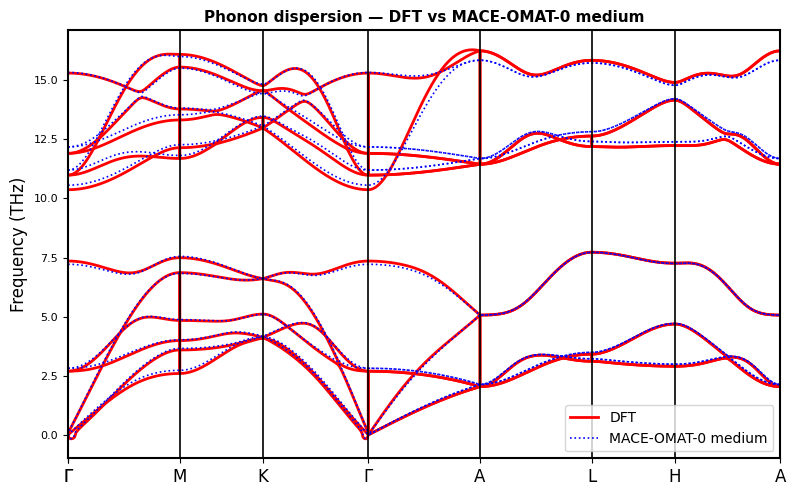

Saved: comparison_MACE.pdf


In [30]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def read_band_yaml(filename):
    with open(filename) as f:
        band_yaml = yaml.safe_load(f)

    qpoints = []
    frequencies = []

    for qpoint in band_yaml['phonon']:
        qpoints.append(qpoint['q-position'])
        freq = [mode['frequency'] for mode in qpoint['band']]
        frequencies.append(freq)

    qpoints = np.array(qpoints)
    frequencies = np.array(frequencies).T  # shape: (n_modes, n_qpoints)

    q_dist = [0.0]
    for i in range(1, len(qpoints)):
        dq = np.linalg.norm(qpoints[i] - qpoints[i-1])
        q_dist.append(q_dist[-1] + dq)
    q_dist = np.array(q_dist)

    return q_dist, frequencies

# ===== High-symmetry points =====
high_sym_idx   = [0, 101, 202, 303, 404, 505, 606, 706]
high_sym_labels = ["Γ", "M", "K", "Γ", "A", "L", "H", "A"]
last_idx = high_sym_idx[-1] + 1
x_lines  = [101, 202, 303, 404, 505, 606]

# ===== Load DFT reference =====
q_dft, freq_dft = read_band_yaml("DFT.yaml")
q_dft    = q_dft[:last_idx]
freq_dft = freq_dft[:, :last_idx]

# ===== MACE models : (filename, short label, color, linestyle) =====
mace_models = [
    ("MACE.yaml",                         "MACE-OMAT-0 medium",          "blue", ":"),
]

def make_ticks(q_ref):
    ticks  = [q_ref[0] - 1e-6] + [q_ref[i] for i in high_sym_idx if 0 <= i <= 706]
    labels = ["Γ"] + [high_sym_labels[high_sym_idx.index(i)] for i in high_sym_idx if 0 <= i <= 706]
    return ticks, labels

# ===== Generate one PDF per MACE model =====
for filename, label, color, linestyle in mace_models:

    q_mace, freq_mace = read_band_yaml(filename)
    q_mace    = q_mace[:last_idx]
    freq_mace = freq_mace[:, :last_idx]

    fig, ax = plt.subplots(figsize=(8, 5))

    # DFT (reference, always red)
    for i, mode in enumerate(freq_dft):
        ax.plot(q_dft, mode, color='red', linewidth=2,
                label='DFT' if i == 0 else "")

    # MACE model
    for i, mode in enumerate(freq_mace):
        ax.plot(q_mace, mode, color=color, linestyle=linestyle, linewidth=1.2,
                label=label if i == 0 else "")

    # Axes limits & ticks
    ax.set_xlim(q_dft[0], q_dft[706])
    ticks, tick_labels = make_ticks(q_dft)
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=12)

    # Vertical lines at high-symmetry points
    for idx in x_lines:
        ax.axvline(x=q_dft[idx], color='black', linewidth=1.2)

    # Labels & formatting
    ax.set_ylabel("Frequency (THz)", fontsize=12)
    ax.set_title(f"Phonon dispersion — DFT vs {label}", fontsize=11, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.legend(loc="lower right", fontsize=10)
    plt.tight_layout()

    #ploting
    plt.tight_layout()
    plt.show()
    
    # Save as vector PDF
    safe_name = filename.replace(".yaml", "").replace(" ", "_")
    pdf_name  = f"comparison_{safe_name}.pdf"
    with PdfPages(pdf_name) as pdf:
        pdf.savefig(fig, bbox_inches='tight')

    plt.close(fig)
    print(f"Saved: {pdf_name}")

---
## Step 7 — 3rd-Order Force Constants (FC3)


In [9]:
ph_atoms3 = ase_to_phonopy(relaxed_atoms)
phono3 = Phono3py(
    ph_atoms3,
    supercell_matrix=SC3_MATRIX,
    primitive_matrix='auto',
    log_level=1
)
phono3.generate_displacements(distance=DISPLACEMENT_3)
sc3     = phono3.supercells_with_displacements
n_valid = sum(1 for s in sc3 if s is not None)
sample  = next(s for s in sc3 if s is not None)
print(f'FC3: {n_valid} supercells  ({len(sample)} atoms each)  device: {DEVICE}')

phono3.forces = evaluate_forces(sc3, label='FC3')
phono3.produce_fc3()
phono3.produce_fc2()
print('\n FC3 done.')

FC3: 582 supercells  (32 atoms each)  device: cpu
  FC3        1/582  elapsed     0s  ETA   118s
  FC3       29/582  elapsed     5s  ETA   100s
  FC3       58/582  elapsed    10s  ETA    95s
  FC3       87/582  elapsed    16s  ETA    90s
  FC3      116/582  elapsed    21s  ETA    85s
  FC3      145/582  elapsed    26s  ETA    79s
  FC3      174/582  elapsed    32s  ETA    74s
  FC3      203/582  elapsed    37s  ETA    69s
  FC3      232/582  elapsed    42s  ETA    64s
  FC3      261/582  elapsed    48s  ETA    59s
  FC3      290/582  elapsed    53s  ETA    54s
  FC3      319/582  elapsed    59s  ETA    48s
  FC3      348/582  elapsed    64s  ETA    43s
  FC3      377/582  elapsed    70s  ETA    38s
  FC3      406/582  elapsed    75s  ETA    33s
  FC3      435/582  elapsed    81s  ETA    27s
  FC3      464/582  elapsed    86s  ETA    22s
  FC3      493/582  elapsed    92s  ETA    17s
  FC3      522/582  elapsed    97s  ETA    11s
  FC3      551/582  elapsed   102s  ETA     6s
  FC3     

---
## Step 8 — Thermal Conductivity: FC2+RTA · FC3+RTA · FC3+LBTE

Three levels of calculation run back-to-back for direct comparison.

In [12]:
temps_C = np.linspace(TEMP_MIN_C, TEMP_MAX_C, N_TEMPS)
temps_K = temps_C + 273.15

# ── FC2 + RTA  (simplified Umklapp τ model) ──────────────────────
# Uses only the harmonic FC2 — no FC3 needed
# τ model: τ ∝ 1/T (crude Umklapp approximation)

def kappa_FC2_RTA(phonon_obj, temps_K, mesh=Q_MESH, tau0=1.4e-10):
    """
    Simplified thermal conductivity using FC2 + RTA with Umklapp τ model.
    tau(q,s,T) = tau0 * (300 / T)   — simple 1/T scaling
    This is fast but physically approximate.
    """
    phonon_obj.run_mesh(mesh)
    mesh_dict  = phonon_obj.get_mesh_dict()
    freqs_mesh = mesh_dict['frequencies']   # (Nq, Nbands) THz
    qpoints    = mesh_dict['qpoints']
    nbands     = freqs_mesh.shape[1]
    Nq         = len(qpoints)
    volume = phonon_obj.unitcell.volume   # Å³

    # Group velocities via finite difference in q
    delta_q = 0.01
    gv = np.zeros((Nq, nbands, 3))
    for i, q in enumerate(qpoints):
        for dim in range(3):
            qp = q.copy(); qp[dim] += delta_q
            qm = q.copy(); qm[dim] -= delta_q
            phonon_obj.run_qpoints([qp])
            fp = phonon_obj.get_qpoints_dict()['frequencies'][0]
            phonon_obj.run_qpoints([qm])
            fm = phonon_obj.get_qpoints_dict()['frequencies'][0]
            gv[i, :, dim] = (fp - fm) / (2 * delta_q * THzToEv * 2 * np.pi)

    kappa_all = np.zeros((len(temps_K), 3, 3))
    for t_idx, T in enumerate(temps_K):
        for qi in range(Nq):
            for b in range(nbands):
                freq = freqs_mesh[qi, b]
                if freq > 0.1:
                    v   = gv[qi, b]
                    x   = THzToEv * freq / (Kb * T)
                    ex  = np.exp(x)
                    C   = Kb * x**2 * ex / (ex - 1.0)**2
                    tau = tau0 * (300.0 / T)
                    kappa_all[t_idx] += np.outer(v, v) * C * tau
        kappa_all[t_idx] *= (1e30 / volume) * THzToEv**2 * Hbar / (Kb * T**2)

    # Extract diagonal (xx, yy, zz) → VRH average
    kappa_avg = np.array([vrh_average([kappa_all[i,0,0],
                                       kappa_all[i,1,1],
                                       kappa_all[i,2,2]])
                          for i in range(len(temps_K))])
    return kappa_all, kappa_avg


print('Computing FC2 + RTA (simplified τ model)...')
t0 = time()
kappa_fc2_tensor, kappa_fc2_rta_avg = kappa_FC2_RTA(phonon, temps_K)
print(f' FC2+RTA done in {time()-t0:.0f}s')
idx300 = np.argmin(np.abs(temps_C - 300))
print(f'   κ_avg at 300°C: {kappa_fc2_rta_avg[idx300]:.2f} W/mK')

Computing FC2 + RTA (simplified τ model)...
✅ FC2+RTA done in 0s
   κ_avg at 300°C: 1.94 W/mK


In [23]:
import numpy as np
from time import time

def run_kappa_phono3(phono3_obj, temps_K, mesh=None, use_lbte=False):
    """
    Runs Phono3py for a list of temperatures and extracts the full result matrix.
    """
    solver_name = 'Full LBTE' if use_lbte else 'RTA'
    print(f'Starting calculation: FC3 + {solver_name} for {len(temps_K)} points...')
    t_start = time()
    
    # 1. Update the q-point mesh if provided
    if mesh is not None:
        phono3_obj.mesh_numbers = mesh
        
    # 2. Initialize the interaction (required before running)
    phono3_obj.init_phph_interaction()
    
    # 3. Run the solver for ALL temperatures at once
    # Phono3py will iterate internally and print the results to your terminal
    phono3_obj.run_thermal_conductivity(
        temperatures=list(temps_K),
        is_LBTE=use_lbte,
        write_kappa=False
    )
    
    # 4. CRITICAL STEP: Extract the full (N_temps, 6) matrix
    # If temps_K has 30 values, kappa_full will have 30 rows.
    kappa_full = phono3_obj.thermal_conductivity.kappa
    
    # 5. Calculate the average for each of the 30 temperatures
    # We take the first 3 columns (xx, yy, zz) and average them
    kappa_avg = (kappa_full[:, 0] + kappa_full[:, 1] + kappa_full[:, 2]) / 3.0
    
    duration = time() - t_start
    print(f' Finished in {duration:.1f}s. Array shape: {kappa_full.shape}')
    
    return kappa_full, kappa_avg

In [24]:
temps_K = np.linspace(TEMP_MIN_C + 273.15, TEMP_MAX_C + 273.15, N_TEMPS)
temps_C = temps_K - 273.15

# --- Run RTA (Fast) ---
kappa_fc3_rta, kappa_fc3_rta_avg = run_kappa_phono3(
    phono3, temps_K, mesh=Q_MESH, use_lbte=False
)

# --- Run LBTE (This takes ~15-20 mins) ---
kappa_fc3_lbte, kappa_fc3_lbte_avg = run_kappa_phono3(
    phono3, temps_K, mesh=Q_MESH, use_lbte=True
)

# --- Final Check ---
print(f"Data ready for plotting: {len(kappa_fc3_lbte_avg)} points found.")

Starting calculation: FC3 + RTA for 30 points...
-------------------- Lattice thermal conductivity (RTA) --------------------
======================= Grid point 0 (1/216) =======================
q-point: ( 0.00  0.00  0.00)
Number of triplets: 216
Frequency     group velocity (x, y, z)     |gv|
  -0.001   (   0.000    0.000    0.000)    0.000
  -0.000   (   0.000    0.000    0.000)    0.000
  -0.000   (   0.000    0.000    0.000)    0.000
   2.554   (   0.000    0.000   -0.000)    0.000
   2.554   (  -0.000   -0.000    0.000)    0.000
   7.463   (   0.000    0.000    0.000)    0.000
  11.437   (   0.000    0.000    0.000)    0.000
  12.132   (   0.000    0.000    0.000)    0.000
  12.132   (  -0.000   -0.000    0.000)    0.000
  13.112   (   0.000    0.000    0.000)    0.000
  13.112   (  -0.000   -0.000    0.000)    0.000
  16.164   (   0.000    0.000    0.000)    0.000
======================= Grid point 1 (2/216) =======================
q-point: ( 0.07  0.00  0.00)
Number of triplets

In [25]:
# Squeeze the arrays to remove the extra dimension [1, 30, 6] -> [30, 6]
kappa_fc3_lbte = np.squeeze(kappa_fc3_lbte)
kappa_fc3_rta = np.squeeze(kappa_fc3_rta)

# Re-calculate the averages on the correct axis
kappa_fc3_lbte_avg = (kappa_fc3_lbte[:, 0] + kappa_fc3_lbte[:, 1] + kappa_fc3_lbte[:, 2]) / 3.0
kappa_fc3_rta_avg = (kappa_fc3_rta[:, 0] + kappa_fc3_rta[:, 1] + kappa_fc3_rta[:, 2]) / 3.0

print(f"New Shape: {kappa_fc3_lbte.shape}") # Should be (30, 6)
print(f"Data points for plotting: {len(kappa_fc3_lbte_avg)}") # Should be 30

New Shape: (30, 6)
Data points for plotting: 30


---
## Step 9 — Results Table

In [26]:
import numpy as np
exp_interp = np.interp(temps_C, exp_ZnO[:,0], exp_ZnO[:,1],
                       left=np.nan, right=np.nan)

print(f'{"T(°C)":>7}  {"Exp":>8}  '
      f'{"FC2+RTA":>9}  {"FC3+RTA":>9}  {"FC3+LBTE":>10}  '
      f'{"Δ_LBTE":>8}')
print('─' * 72)

for i, T in enumerate(temps_C):
    ev = exp_interp[i]
    exp_s = f'{ev:8.2f}' if not np.isnan(ev) else '     N/A'
    dl    = f'{(kappa_fc3_lbte_avg[i]-ev)/ev*100:+7.1f}%' if not np.isnan(ev) else '       —'   
    print(f'{T:7.1f}  {exp_s}  '
          f'{kappa_fc2_rta_avg[i]:9.2f}  '
          f'{kappa_fc3_rta_avg[i]:9.2f}  '
          f'{kappa_fc3_lbte_avg[i]:10.2f}  {dl}')

mask = ~np.isnan(exp_interp)
print('─' * 72)
for name, arr in [('FC2+RTA ', kappa_fc2_rta_avg),
                  ('FC3+RTA ', kappa_fc3_rta_avg),
                  ('FC3+LBTE', kappa_fc3_lbte_avg)]:
    mre  = np.mean(np.abs(arr[mask] - exp_interp[mask]) / exp_interp[mask]) * 100
    bias = np.mean(arr[mask] - exp_interp[mask])
    print(f'  {name}: MRE = {mre:.1f}%   bias = {bias:+.2f} W/mK')

  T(°C)       Exp    FC2+RTA    FC3+RTA    FC3+LBTE    Δ_LBTE
────────────────────────────────────────────────────────────────────────
   25.0     47.00      12.52      47.86       50.44     +7.3%
   48.3     41.88      10.20      44.00       46.36    +10.7%
   71.6     36.76       8.41      40.74       42.91    +16.7%
   94.8     34.26       7.01      37.93       39.95    +16.6%
  118.1     32.21       5.91      35.50       37.39    +16.1%
  141.4     30.16       5.02      33.37       35.14    +16.5%
  164.7     28.11       4.30      31.48       33.15    +17.9%
  187.9     26.06       3.71      29.80       31.38    +20.4%
  211.2     24.48       3.22      28.29       29.79    +21.7%
  234.5     23.40       2.81      26.93       28.36    +21.2%
  257.8     22.32       2.47      25.70       27.06    +21.2%
  281.0     21.24       2.18      24.58       25.88    +21.8%
  304.3     20.16       1.94      23.55       24.80    +23.0%
  327.6     19.10       1.73      22.61       23.81    +24.

---
## Step 10 — Plots

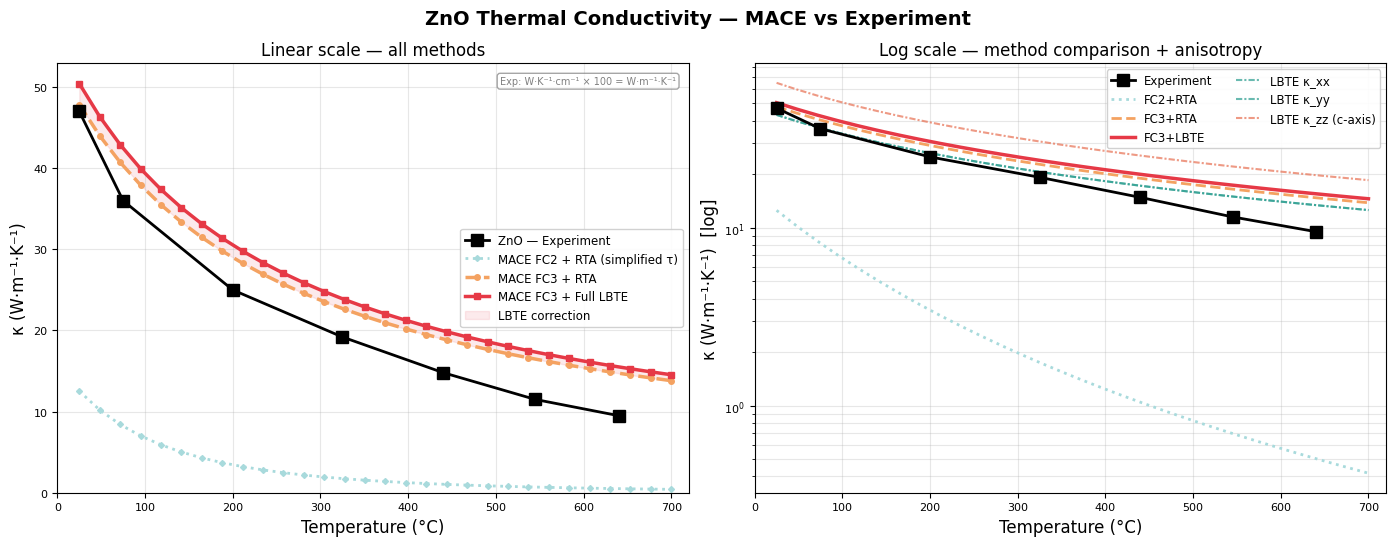

Saved → ZnO_kappa_all_methods.png


In [27]:
# ── Figure 1: Full comparison — all methods vs experiment ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('ZnO Thermal Conductivity — MACE vs Experiment',
             fontsize=14, fontweight='bold')

# Panel 1 — Linear scale
ax = axes[0]
ax.plot(exp_ZnO[:,0], exp_ZnO[:,1],
        'ks-', ms=9, lw=2, zorder=6, label='ZnO — Experiment')
ax.plot(temps_C, kappa_fc2_rta_avg,
        color='#A8DADC', lw=2, ls=':', marker='D', ms=3,
        label='MACE FC2 + RTA (simplified τ)')
ax.plot(temps_C, kappa_fc3_rta_avg,
        color='#F4A261', lw=2.5, ls='--', marker='o', ms=4,
        label='MACE FC3 + RTA')
ax.plot(temps_C, kappa_fc3_lbte_avg,
        color='#E63946', lw=2.5, ls='-', marker='s', ms=4,
        label='MACE FC3 + Full LBTE')
ax.fill_between(temps_C, kappa_fc3_rta_avg, kappa_fc3_lbte_avg,
          alpha=0.10, color='#E63946', label='LBTE correction')

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('κ (W·m⁻¹·K⁻¹)', fontsize=12)
ax.set_title('Linear scale — all methods', fontsize=12)
ax.set_xlim(0, 720)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8.5, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.annotate('Exp: W·K⁻¹·cm⁻¹ × 100 = W·m⁻¹·K⁻¹',
            xy=(0.98, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=7, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.7))

# Panel 2 — Log scale + anisotropy (LBTE)
ax2 = axes[1]
ax2.semilogy(exp_ZnO[:,0], exp_ZnO[:,1],
             'ks-', ms=9, lw=2, zorder=6, label='Experiment')
ax2.semilogy(temps_C, kappa_fc2_rta_avg,
             color='#A8DADC', lw=2, ls=':', label='FC2+RTA')
ax2.semilogy(temps_C, kappa_fc3_rta_avg,
             color='#F4A261', lw=2, ls='--', label='FC3+RTA')
ax2.semilogy(temps_C, kappa_fc3_lbte_avg,
             color='#E63946', lw=2.5, ls='-', label='FC3+LBTE')

# Directional anisotropy (LBTE only)
colors_dir = ['#2A9D8F', '#2A9D8F', '#E76F51']
dir_labels = ['κ_xx', 'κ_yy', 'κ_zz (c-axis)']
for j, (lbl, clr) in enumerate(zip(dir_labels, colors_dir)):
    ax2.semilogy(temps_C, kappa_fc3_lbte[:,j],
                 color=clr, lw=1.5, ls=(0,(3,1,1,1)), alpha=0.7,
                 label=f'LBTE {lbl}')

ax2.set_xlabel('Temperature (°C)', fontsize=12)
ax2.set_ylabel('κ (W·m⁻¹·K⁻¹)  [log]', fontsize=12)
ax2.set_title('Log scale — method comparison + anisotropy', fontsize=12)
ax2.set_xlim(0, 720)
ax2.legend(fontsize=8.5, framealpha=0.9, ncol=2)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('ZnO_kappa_all_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ZnO_kappa_all_methods.png')

### Outputs
| File | Content |
|------|---------|
| `ZnO_phonon_dispersion_MACE_vs_DFT.png` | Phonon bands comparison |
| `ZnO_kappa_all_methods.png` | All κ methods vs experiment |
